# EfficientNet B2 for Multi-class Classification

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import os
import joblib
import json

from torch.utils.data import DataLoader, Dataset
import torch.utils.data as utils
from torchvision import transforms

import torch
import torch.nn as nn
import torch.optim as optim 
import torchvision
from loguru import logger

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from efficientnet_pytorch import EfficientNet
from early_stopping_pytorch import EarlyStopping

from nazi_symbols_classification.training.data_preparation import get_image_paths, load_labels_df
from nazi_symbols_classification.training.torch_dataset_preparation import ImageData, get_device, to_device, ToDeviceLoader
%matplotlib inline

## Data Preparation

In [3]:
dir_name = os.path.dirname(os.getcwd())
dataset_path = f"{dir_name}/datasets/nazi-symbols-classification"

In [5]:
train_labels_df = load_labels_df(dataset_path, "train", binary=False)
valid_labels_df = load_labels_df(dataset_path, "val", binary=False)
test_labels_df = load_labels_df(dataset_path, "test", binary=False)

2025-06-13 20:57:54.097 | INFO     | __main__:load_labels_df:3 - Number of images in train is 9009
2025-06-13 20:57:54.104 | INFO     | __main__:load_labels_df:3 - Number of images in val is 1934
2025-06-13 20:57:54.108 | INFO     | __main__:load_labels_df:3 - Number of images in test is 1944


### Remapping Labels

In [6]:
remap_dict = {
    'nazi_cls': {
        "atomwaffen": "neo-nazi", 
        "blood_honor_emblem": "neo-nazi", 
        "celtic_cross": "neo-nazi", 
        "combat_18_emblem": "neo-nazi", 
        "golden_dawn": "neo-nazi", 
        "hammerskins": "neo-nazi", 
        "identitaere_bewegung_emblem": "neo-nazi", 
        "kolovrat": "neo-nazi", 
        "national_rebirth_poland": "neo-nazi", 
        "volksfront_emblem": "neo-nazi", 
        "doppelsiegrune": "siegrune"
    }
}
train_labels_df = train_labels_df.replace(remap_dict)
valid_labels_df = valid_labels_df.replace(remap_dict)
test_labels_df = test_labels_df.replace(remap_dict)

### Encoding Labels

In [7]:
le = LabelEncoder()

le.fit(train_labels_df.nazi_cls)
train_labels_df["nazi_cls_encoded"] = le.transform(train_labels_df.nazi_cls)
valid_labels_df["nazi_cls_encoded"] = le.transform(valid_labels_df.nazi_cls)
test_labels_df["nazi_cls_encoded"] = le.transform(test_labels_df.nazi_cls)

### Data Transformations and Dataset Creation

In [9]:
data_transf = transforms.Compose([transforms.ToPILImage(), 
                                  transforms.Grayscale(num_output_channels=3),
                                  transforms.Resize((224, 224)), 
                                  transforms.ToTensor(),
                                  transforms.Normalize((0.5,), (0.5,))])

def create_datasets(batch_size, dataset_path=dataset_path):
    train_data = ImageData(df = train_labels_df,
                           data_directory = os.path.join(dataset_path, 'train'),
                           transform = data_transf,
                           label_column = "nazi_cls_encoded")
    train_loader = DataLoader(dataset = train_data, batch_size = batch_size, shuffle=True)
    
    valid_data = ImageData(df = valid_labels_df, 
                           data_directory = os.path.join(dataset_path, 'val'), 
                           transform = data_transf,
                           label_column = "nazi_cls_encoded")
    valid_loader = DataLoader(dataset = valid_data, batch_size = batch_size, shuffle=False)

    test_data = ImageData(df = test_labels_df, 
                           data_directory = os.path.join(dataset_path, 'test'), 
                           transform = data_transf,
                           label_column = "nazi_cls_encoded")
    test_loader = DataLoader(dataset = test_data, batch_size = batch_size, shuffle=False)
    return train_loader, valid_loader, test_loader

In [10]:
batch_size = 48

train_loader, valid_loader, test_loader = create_datasets(batch_size, dataset_path)

In [12]:
device = get_device()
print(device)

train_dl = ToDeviceLoader(train_loader, device)
valid_dl = ToDeviceLoader(valid_loader, device)
test_dl = ToDeviceLoader(test_loader, device)

cuda


### Data Sanity Check

tensor([12, 11,  8, 11, 11, 11,  9, 11,  0, 11,  8,  8,  4, 11, 11, 11])


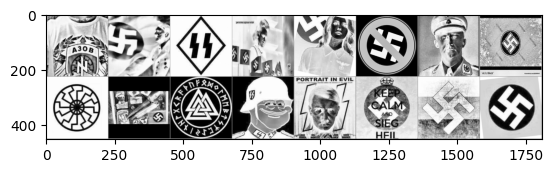

In [13]:
# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(train_loader)
images, labels = next(dataiter)

print(labels)

# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)

## Model Preparation

In [14]:
model = EfficientNet.from_name('efficientnet-b2', num_classes=13)

In [15]:
# Unfreezing model weights
for param in model.parameters():
    param.requires_grad = True

In [16]:
model = model.to('cuda')

In [17]:
optimizer = torch.optim.Adam(model.parameters())

In [18]:
loss_fn = nn.CrossEntropyLoss()

In [19]:
def train_model(model, patience, n_epochs):
    
    # to track the training loss as the model trains
    train_losses = []
    # to track the validation loss as the model trains
    valid_losses = []
    # to track the average training loss per epoch as the model trains
    avg_train_losses = []
    # to track the average validation loss per epoch as the model trains
    avg_valid_losses = [] 
    
    # initialize the early_stopping object
    early_stopping = EarlyStopping(patience=patience, verbose=True, path="efficientnet-output/efficientnet-b2-multiple-pretrained-size-224-batch-48.pt")
    
    for epoch in range(n_epochs):

        ###################
        # train the model #
        ###################
        model.train() # prep model for training
        for i, (data, target) in enumerate(train_dl):
            # Zero your gradients for every batch!
            optimizer.zero_grad()
    
            # Make predictions for this batch
            output = model(data)

            # m = nn.Softmax(dim=1)
            
            # Compute the loss and its gradients
            loss = loss_fn(output, target)
            loss.backward()
    
            # Adjust learning weights
            optimizer.step()
            # record training loss
            train_losses.append(loss.item())

        ######################    
        # validate the model #
        ######################
        model.eval() # prep model for evaluation
        for data, target in valid_dl:
            # forward pass: compute predicted outputs by passing inputs to the model
            output = model(data)
            # m = nn.Softmax(dim=1)
            # calculate the loss
            loss = loss_fn(output, target)
            # record validation loss
            valid_losses.append(loss.item())

        # print training/validation statistics 
        # calculate average loss over an epoch
        train_loss = np.average(train_losses)
        valid_loss = np.average(valid_losses)
        avg_train_losses.append(train_loss)
        avg_valid_losses.append(valid_loss)
        
        epoch_len = len(str(n_epochs))
        
        print_msg = (f'[{(epoch + 1):>{epoch_len}}/{(n_epochs + 1):>{epoch_len}}] ' +
                     f'train_loss: {train_loss:.5f} ' +
                     f'valid_loss: {valid_loss:.5f}')
        
        print(print_msg)
        
        # clear lists to track next epoch
        train_losses = []
        valid_losses = []
        
        # early_stopping needs the validation loss to check if it has decresed, 
        # and if it has, it will make a checkpoint of the current model
        early_stopping(valid_loss, model)
        
        if early_stopping.early_stop:
            print("Early stopping")
            break
        
    # load the last checkpoint with the best model
    model.load_state_dict(torch.load('efficientnet-output/efficientnet-b2-multiple-pretrained-size-224-batch-48.pt', weights_only=True))

    return  model, avg_train_losses, avg_valid_losses

## Model Training

In [ ]:
%%time
# Training model for 5 epochs and logging the time required for the entire training process
# Initializing in a separate cell so we can easily add more epochs to the same run
n_epochs = 100

# early stopping patience; how long to wait after last time validation loss improved.
patience = 10

model, train_loss, valid_loss = train_model(model, batch_size, patience, n_epochs)

In [ ]:
history = dict(train_loss=train_loss, valid_loss=valid_loss)

with open('efficientnet-output/efficientnet-multiple-history.json', 'w') as f:
    f.write(json.dumps(history))

## Model Evaluation

In [24]:
model.load_state_dict(torch.load("efficientnet-output/efficientnet-b2-multiple-pretrained-size-224-batch-48.pt", weights_only=True))
model.eval()

EfficientNet(
  (_conv_stem): Conv2dStaticSamePadding(
    3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
    (static_padding): ZeroPad2d((0, 1, 0, 1))
  )
  (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
  (_blocks): ModuleList(
    (0): MBConvBlock(
      (_depthwise_conv): Conv2dStaticSamePadding(
        32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
        (static_padding): ZeroPad2d((1, 1, 1, 1))
      )
      (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_se_reduce): Conv2dStaticSamePadding(
        32, 8, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_se_expand): Conv2dStaticSamePadding(
        8, 32, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_project_conv): Conv2dStaticSamePadding(
        32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False
    

### Evaluating on test Set

In [25]:
outputs = []
y_true = []
for images, labels in test_dl:
    with torch.no_grad():
        out = model(images)
    m = nn.Softmax(dim=1)
    _, predicted = torch.max(m(out), 1)
    y_true += to_device(labels, "cpu")
    outputs += to_device(predicted, "cpu")

In [26]:
print(classification_report(y_true, outputs, digits=3))
accuracy_score(y_true, outputs)

              precision    recall  f1-score   support

           0      0.762     0.798     0.780       124
           1      0.900     0.750     0.818        12
           2      0.643     0.562     0.600        16
           3      0.795     0.939     0.861        33
           4      0.809     0.757     0.782       185
           5      0.500     0.200     0.286         5
           6      1.000     1.000     1.000         3
           7      0.665     0.791     0.723       158
           8      0.802     0.667     0.728       261
           9      0.669     0.745     0.705       220
          10      0.571     0.500     0.533         8
          11      0.890     0.880     0.885       886
          12      0.475     0.576     0.521        33

    accuracy                          0.801      1944
   macro avg      0.729     0.705     0.709      1944
weighted avg      0.806     0.801     0.802      1944



0.801440329218107

In [27]:
le.classes_

array(['black_sun', 'british_union_of_fascist', 'broken_sun_cross',
       'happy_merchant', 'hitler', 'hitler_salute', 'judenstern',
       'neo-nazi', 'siegrune', 'ss_skull', 'sturmabteilung_emblem',
       'swastika', 'wolfsangel'], dtype=object)

In [28]:
predicted_result = dict(y_true=y_true, outputs=outputs)
joblib.dump(predicted_result, "efficientnet-output/efficientnet-multi-predicted-result.joblib")

['efficientnet-output/efficientnet-multi-predicted-result.joblib']